### Linear Regression Using the Model Class
This notebook is based on the Coursera Course: Foundations and Core Concepts of PyTorch.

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

          Unnamed: 0   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  


<Axes: xlabel='wt', ylabel='mpg'>

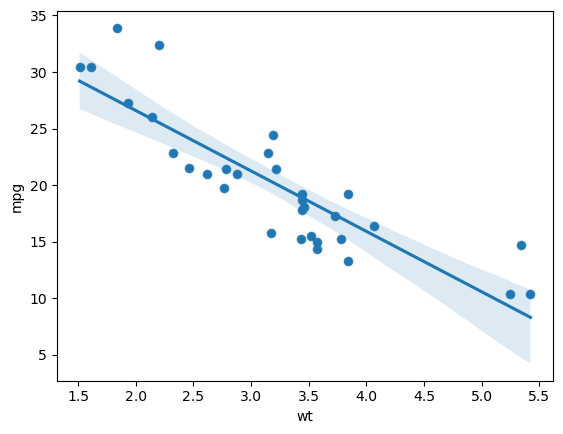

In [5]:
# Data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
print(cars.head())

# Visualize the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

In [12]:
# Convert the data to tensor formats
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
print(X_np[:4])  # Peak at the first four values to see the shape

y_list = cars.mpg.values.tolist()
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# Create tensors out of the data (two ways)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

print("X.shape: {}".format(X.shape))
print("y.shape: {}".format(y_true.shape))

[[2.62 ]
 [2.875]
 [2.32 ]
 [3.215]]
X.shape: torch.Size([32, 1])
y.shape: torch.Size([32, 1])


In [9]:
# Define the Model Class

class LinearRegressionTorch(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

In [58]:
INPUT_DIM = 1
OUTPUT_DIM = 1

model = LinearRegressionTorch(INPUT_DIM, OUTPUT_DIM)

# Linear regression makes MSE appropriate
LOSS_FUNC = nn.MSELoss()
LR = 0.03
OPTIMIZER = torch.optim.SGD(model.parameters(), lr=LR)

NUM_EPOCHS = 1000


In [ ]:
losses, slopes, biases = [], [], []

for epoch in range(NUM_EPOCHS):
    OPTIMIZER.zero_grad()

    # forward pass
    y_pred = model(X)

    # compute loss
    loss = LOSS_FUNC(y_pred, y_true)
    loss.backward()

    OPTIMIZER.step()

    slope = model.linear.weight[0, 0].item()
    bias  = model.linear.bias[0].item()

    slopes.append(slope)
    biases.append(bias)

    print_every = 100

    loss_val = loss.item()
    losses.append(loss_val)

    if epoch % print_every == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss_val:.6f}")

# We can compare these to the statistical regression model to see how close we are
print(f"Bias at end: {biases[-1]}")
print(f"Slope at the end: {slopes[-1]}")

Epoch     0 | Loss: 8.709314
Epoch   100 | Loss: 8.702272
Epoch   200 | Loss: 8.699450
Epoch   300 | Loss: 8.698317
Epoch   400 | Loss: 8.697865
Epoch   500 | Loss: 8.697683
Epoch   600 | Loss: 8.697610
Epoch   700 | Loss: 8.697581
Epoch   800 | Loss: 8.697570
Epoch   900 | Loss: 8.697564
Bias at end: 37.28119659423828
Slope at the end: -5.3433427810668945


<Axes: >

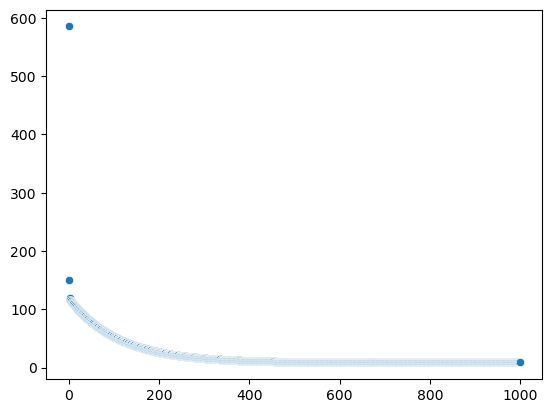

In [60]:
# Visualize the model training
sns.scatterplot(x=range(NUM_EPOCHS), y=losses)

<Axes: >

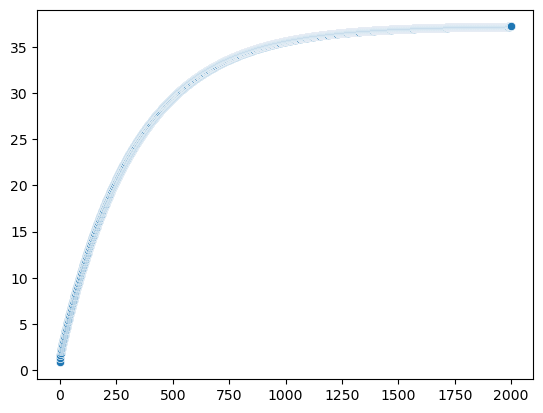

In [43]:
# Visualize the bias develpment
sns.scatterplot(x=range(NUM_EPOCHS), y=biases)

<Axes: >

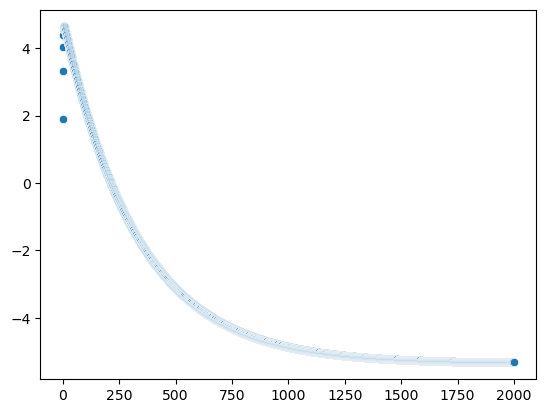

In [44]:
# Visualize the slopes
sns.scatterplot(x=range(NUM_EPOCHS), y=slopes)

<Axes: >

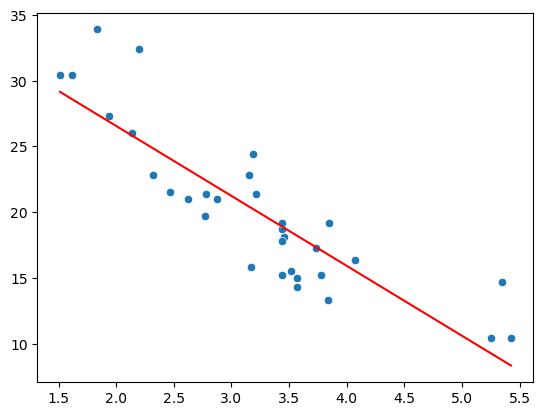

In [45]:
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')